# 📑 Student Assignment

> **Format:** Scientific report (approx. 10 pages)  
> **Hand in time:** 30.09.2026  
> **Hand in to:** Prof. Marzahn

---

### 📋 Topics that need to be addressed

* **Methodology Review:** Discussion of advantages and disadvantages of indices, radiative transfer model and crop models (**take agricultural applications into account, use your background experience**).
* **Model Calibration:** Calibration of Wofost for wheat/maize field (**What parameter values were used?**).
* **Calibration Analysis:** Discussion of calibration (**purpose, usage, etc.**).
* **Data Evaluation:** 
    * Discussion of model input data sets (**Which model input data sets were used?**).
    * Discussion of model results compared to in-situ data used for calibration purpose.
* **Synthesis:** Transferability of the calibrated Wofost model parameters

## 🌾 WOFOST Model

📘 **Reference:** [WOFOST Handbook (PDF)](https://backend.wur.nl/sites/default/files/2025-10/Gentle-WOFOST-2024.pdf)

---

### ⚙️ Modifiable Parameters

The model configuration can be adjusted across four core data domains:

* **🌤️ Weather Data:** Climate forcing inputs (radiation, temperature, rainfall, etc.).
* **🟫 Soil Data:** Physical soil properties, water retention, and rooting limits.
* **🌽 Crop Data:** Genetic crop parameters and development rates.
* **🚜 WOFOST Parameter Set:** Agromanagement settings (sowing dates, harvesting dates, and field management).

---
### 🌤️ Weather data

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

from pcse.input import NASAPowerWeatherDataProvider

# e.g. Rostock
lat = 54.0887
lon = 12.14049

# Fetch the data
meteo_data = NASAPowerWeatherDataProvider(latitude=lat, longitude=lon)

print(meteo_data)


Bad key keymap.all_axes in file matplotlibrc, line 398 ('keymap.all_axes : a                 # enable all axes')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


Weather data provided by: NASAPowerWeatherDataProvider
--------Description---------
NASA/POWER Source Native Resolution Daily Data
----Site characteristics----
Elevation:   26.4
Latitude:  54.089
Longitude: 12.140
Data available for 1984-01-01 - 2026-07-03
Number of missing days: 5



---
### 🟫 Soil data

In [2]:
from pcse.input import CABOFileReader

### --- Things to Change ---
soil_name = "ec4.new"
### ---
# other soil data are stored in the folder "SF_data/Wofost_soil"
soil_path = os.path.join("SF_data/Wofost_soil", soil_name)

soil_data = CABOFileReader(soil_path)

print(soil_data)

** $Id: ec4.new 1.2 1997/09/18 17:33:54 LEM release $
**
** SOIL DATA FILE for use with WOFOST Version 5.0, June 1990
**
** EC-4 fine
------------------------------------
SMW: 0.3 <class 'float'>
SMFCF: 0.46 <class 'float'>
SM0: 0.57 <class 'float'>
CRAIRC: 0.05 <class 'float'>
K0: 10.789 <class 'float'>
SOPE: 0.55 <class 'float'>
KSUB: 0.37 <class 'float'>
SPADS: 0.05 <class 'float'>
SPODS: 0.025 <class 'float'>
SPASS: 0.1 <class 'float'>
SPOSS: 0.04 <class 'float'>
DEFLIM: -0.3 <class 'float'>
SOLNAM: EC4-fine <class 'str'>
SMTAB: [-1.0, 0.57, 1.0, 0.533, 1.3, 0.524, 1.491, 0.515, 2.0, 0.486, 2.4, 0.451, 2.7, 0.42, 3.4, 0.35, 4.204, 0.3, 6.0, 0.27] <class 'list'>
CONTAB: [0.0, 1.033, 1.0, -0.824, 1.3, -1.155, 1.491, -1.398, 1.7, -1.523, 2.0, -1.959, 2.4, -2.495, 2.7, -2.886, 3.0, -3.276, 3.4, -3.77, 3.7, -4.131, 4.0, -4.481, 4.204, -4.745] <class 'list'>



---
### 🌽 Crop data


In [3]:
from pcse.fileinput import YAMLCropDataProvider

# Initialize the built-in database
crop_db = YAMLCropDataProvider()

# Get the dictionary of crops and varieties
crop_dict = crop_db.get_crops_varieties()

# Define the priority crops
priority_crops = ['wheat', 'maize']

print("--- Priority Crops ---")
# Print priority crops
for crop_name in priority_crops:
    if crop_name in crop_dict:
        varieties = crop_dict[crop_name]
        print(f"\n Crop: {crop_name}")
        for variety in varieties:
            print(f"  └── {variety}")

print("\n-------------------------------------------")

# Collect all other crops and join them into a single line
other_crops = [crop.upper() for crop in crop_dict.keys() if crop not in priority_crops]

print("Other Available Crops:", ", ".join(other_crops))


Importing from `pcse.fileinput` is deprecated and will be removed. Use `pcse.input` instead.
--- Priority Crops ---

 Crop: wheat
  └── Winter_wheat_101
  └── Winter_wheat_102
  └── Winter_wheat_103
  └── Winter_wheat_104
  └── Winter_wheat_105
  └── Winter_wheat_106
  └── Winter_wheat_107
  └── bermude
  └── apache

 Crop: maize
  └── Maize_VanHeemst_1988
  └── Grain_maize_201
  └── Grain_maize_202
  └── Grain_maize_203
  └── Grain_maize_204
  └── Grain_maize_205
  └── Fodder_maize_nl

-------------------------------------------
Other Available Crops: BARLEY, CASSAVA, CHICKPEA, COTTON, COWPEA, FABABEAN, GROUNDNUT, MILLET, MUNGBEAN, PIGEONPEA, POTATO, RAPESEED, RICE, SORGHUM, SOYBEAN, SUGARBEET, SUGARCANE, SUNFLOWER, SWEETPOTATO, TOBACCO, SEED_ONION


In [4]:
### --- Things to Change ---
crop = 'wheat'
crop_variety = 'Winter_wheat_101'
### ---

crop_db.set_active_crop(crop, crop_variety)

print("--- Full Active Crop Parameters ---")

for parameter, value in crop_db.items():
    if isinstance(value, list):
        print(f"🔹 {parameter}:")
        print(f"   {value}")
    else:
        print(f"🔹 {parameter}: {value}")

--- Full Active Crop Parameters ---
🔹 CO2EFFTB:
   [40.0, 0.0, 360.0, 1.0, 720.0, 1.11, 1000.0, 1.11, 2000.0, 1.11]
🔹 CO2TRATB:
   [40.0, 0.0, 360.0, 1.0, 720.0, 0.9, 1000.0, 0.9, 2000.0, 0.9]
🔹 CO2AMAXTB:
   [40.0, 0.0, 360.0, 1.0, 720.0, 1.6, 1000.0, 1.9, 2000.0, 1.9]
🔹 TBASEM: 0.0
🔹 TEFFMX: 30.0
🔹 TSUMEM: 120
🔹 IDSL: 2
🔹 DLO: 16.8
🔹 DLC: 8.0
🔹 TSUM1: 543
🔹 TSUM2: 1194
🔹 DTSMTB:
   [0.0, 0.0, 30.0, 30.0, 45.0, 30.0]
🔹 DVSI: 0.0
🔹 DVSEND: 2.0
🔹 VERNBASE: 10.0
🔹 VERNSAT: 49.0
🔹 VERNDVS: 0.3
🔹 VERNRTB:
   [-8.0, 0.0, -4.0, 0.0, 3.0, 1.0, 10.0, 1.0, 17.0, 0.0, 20.0, 0.0]
🔹 TDWI: 50.0
🔹 RGRLAI: 0.0082
🔹 SLATB:
   [0.0, 0.00212, 0.5, 0.00212, 2.0, 0.00212]
🔹 SPA: 0.0
🔹 SSATB:
   [0.0, 0.0, 2.0, 0.0]
🔹 SPAN: 31.3
🔹 TBASE: 0.0
🔹 KDIFTB:
   [0.0, 0.6, 2.0, 0.6]
🔹 EFFTB:
   [0.0, 0.45, 40.0, 0.45]
🔹 AMAXTB:
   [0.0, 35.83, 1.0, 35.83, 1.3, 35.83, 2.0, 4.48]
🔹 REFCO2L: 360
🔹 TMPFTB:
   [0.0, 0.01, 10.0, 0.6, 15.0, 1.0, 25.0, 1.0, 35.0, 0.0]
🔹 TMNFTB:
   [0.0, 0.0, 3.0, 1.0]
🔹 CVL: 0.685
🔹 CVO: 

---
## 🚜 Run Wofost model (change parameter set)

In [ ]:
from wofost_utils import *
results = {}
wofost_parameter_sweep2(soil_path, crop, crop_variety, meteo_data);

interactive(children=(DatePicker(value=datetime.date(2017, 3, 1), description='Start Date', step=1), DatePicke…

---
## 📊 In-Situ Data (MNI Test Site - 2017)

### 🌾 Crop Types
* **Winter Wheat**
* **Maize**

### 📏 Field Measurements
* **LAI** (Leaf Area Index)
* **Dry Biomass**
* **Vegetation Height**
* **BBCH** (Crop Phenology Stage)
* **Soil Moisture**

#### 🌾 Prepare vegetation in-situ dataset

In [12]:
### --- Things to Change ---
csv_path = "SF_data/veg_winter_wheat_508.csv"  # Points to the file in the workspace directory
### ---

print("📋 Loading VWC validation dataset...")

# Read the CSV with its semicolon separator
df_csv = pd.read_csv(csv_path, sep=';', low_memory=False)

# Clean whitespaces around header titles to avoid key errors
df_csv.columns = [str(col).strip() for col in df_csv.columns]

# Parse dates and drop rows containing invalid/missing values
df_csv['date'] = pd.to_datetime(df_csv['date'], errors='coerce')
df_csv = df_csv.dropna(subset=['date'])

# Force cast the new ground truth VWC column to standard floats
df_csv['VWC_observed'] = pd.to_numeric(df_csv['VWC kg/m2'], errors='coerce')
df_csv = df_csv.dropna(subset=['VWC_observed']).sort_values('date')


# Convert Dates to Day of Year (1 to 365)
df_csv['DOY'] = df_csv['date'].dt.dayofyear

df_csv = df_csv.rename(columns={'LAI mean': 'LAI'})

print("Original Data with DOY mapping:")
print(df_csv) 
print("\n" + "="*40 + "\n")

# Extend to a full 365-Day Time Series
full_year_doy = pd.DataFrame({'DOY': range(1, 366)})
df_extended = pd.merge(full_year_doy, df_csv, on='DOY', how='left')

# Drop the original date column since it contains NaNs for the extended days
df_extended = df_extended.drop(columns=['date'])

# Handle the days where the crop hasn't grown yet

# A. Before your first observation, LAI should be 0.0 (pre-emergence)
# We fill the first row with 0.0 so the interpolation has a starting point.
df_extended.loc[df_extended['DOY'] == 1, 'LAI'] = 0.0
df_extended.loc[df_extended['DOY'] == 1, 'Dry biomass total kg/m2'] = 0.0

# B. INTERPOLATE: Now this will safely find your real data points!
df_extended['LAI'] = df_extended['LAI'].interpolate(method='linear')
df_extended['Dry biomass total kg/m2'] = df_extended['Dry biomass total kg/m2'].interpolate(method='linear')

# C. After your last observation (post-harvest), LAI should go back to 0.0
df_extended['LAI'] = df_extended['LAI'].fillna(0.0)
df_extended['Dry biomass total kg/m2'] = df_extended['Dry biomass total kg/m2'].fillna(0.0)

print("Extended and Interpolated 365-Day Time Series:")
df_extended.set_index('DOY', inplace=True)

# Let's print a slice where your data points are filling in
print(df_extended.loc[130:145])

📋 Loading VWC validation dataset...
Original Data with DOY mapping:
         date  BBCH median  Chlorophyll mean  Chlorophyll std  \
0  2017-03-24         23.0           53.4067           3.9691   
1  2017-03-28         24.0           52.5467           3.7271   
2  2017-04-05         25.0           55.6667           3.2361   
3  2017-04-10         28.0           47.6857          10.1674   
4  2017-04-21         28.0           42.1267           4.0595   
5  2017-05-02         30.0           40.8867           6.7520   
6  2017-05-10         30.0           40.8867           6.7520   
7  2017-05-16         33.0           56.5800           3.7672   
8  2017-05-26         34.0           61.0000           3.5270   
9  2017-05-29         43.0           56.0533           5.1712   
10 2017-06-02         58.0           59.2867           5.2777   
11 2017-06-08         61.0           53.3400           5.5996   
12 2017-06-13         65.0           54.3200           2.9042   
13 2017-06-19         

#### 💧 Prepare Soil Moisture In-Situ Dataset

* **Port 1:** Soil probe at **5 cm** depth
* **Port 2:** Soil probe at **5 cm** depth
* **Port 3:** Soil probe at **10 cm** depth
* **Port 4:** Soil probe at **10 cm** depth
* **Port 5:** Soil probe at **30 cm** depth

In [13]:
# --- PRE-PROCESSING: Align In-Situ data to DOY ---
# Load data and convert 10-minute intervals to a daily mean
# Port1_SM can be change to other ports (e.g., Port2_SM, ...)
# Load the original soil moisture file

### --- Things to Change ---
df_sm = pd.read_csv("SF_data/sm_winter_wheat_508.csv", parse_dates=['date'])
port = 'Port1_SM'
### ---

df_sm.columns = df_sm.columns.str.strip()
df_sm.set_index('date', inplace=True)
sm = df_sm[port].resample('D').mean().to_frame()

# Extract DOY from the date index and make it the new index
sm['DOY'] = sm.index.dayofyear
sm.set_index('DOY', inplace=True)

# Create a complete 1 to 365 timeline
full_year_doy = pd.DataFrame({'DOY': range(1, 366)}).set_index('DOY')
sm = full_year_doy.join(sm[port], how='left')

print(sm[100:200])

     Port1_SM
DOY          
101  0.274380
102  0.275522
103  0.276115
104  0.277435
105  0.278214
..        ...
196  0.253160
197  0.236147
198  0.226035
199  0.222450
200  0.229409

[100 rows x 1 columns]


---
## 📉 Compare Wofost with in-situ data

### Load Wofost run
- crop_wheat-Winter_wheat_105_soil_ec4_dates.....

In [ ]:
# Define the path to the Wofost CSV file
# Replace 'your_file.csv' with the actual name or path of your file

### --- Things to Change ---
file_path = '/workspaces/H2020_MULTIPLY_training/crop_maize-Maize_VanHeemst_1988_soil_ec4-LIM.csv'
file_path = '/workspaces/H2020_MULTIPLY_training/crop_wheat-Winter_wheat_101_soil_ec4-LIM.csv'
# file_path = 'crop_wheat-Winter_wheat_105_soil_ec4_dates_20170301_to_20170801-span_40.0-tdwi_20.0-tsum1_750.0-tsum2_859.0-tsumem_70.0-rgrlai_0.051000000000000004-wav_5.0-cvo_0.72-cvl_0.72-LIM.csv'
### ---

try:
    # Load the CSV file into a pandas DataFrame
    wofost = pd.read_csv(file_path, index_col="day", parse_dates=True)
    
    # Filter for year 2017 and reset the index
    wofost = wofost[wofost.index.year == 2017]
    wofost = wofost.reset_index()
    
    print("✓ File successfully loaded!")
    print("-" * 40)
    
    # Print the first 5 rows to verify the data structure
    print("First 5 rows of the data:")
    print(wofost.head())
    
    print("-" * 40)
    # Show a summary of data types and missing values
    print("Data structure summary:")
    print(wofost.info())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

✓ File successfully loaded!
----------------------------------------
First 5 rows of the data:
         day  DVS  LAI  TAGP  TWSO  TWLV  TWST  TWRT  TRA  RD        SM  \
0 2017-01-01  NaN  NaN   NaN   NaN   NaN   NaN   NaN  NaN NaN  0.400000   
1 2017-01-02  NaN  NaN   NaN   NaN   NaN   NaN   NaN  NaN NaN  0.428708   
2 2017-01-03  NaN  NaN   NaN   NaN   NaN   NaN   NaN  NaN NaN  0.434308   
3 2017-01-04  NaN  NaN   NaN   NaN   NaN   NaN   NaN  NaN NaN  0.508337   
4 2017-01-05  NaN  NaN   NaN   NaN   NaN   NaN   NaN  NaN NaN  0.491600   

       WWLOW  RFTRA  
0  35.000000    NaN  
1  35.287081    NaN  
2  35.343081    NaN  
3  36.083374    NaN  
4  36.339213    NaN  
----------------------------------------
Data structure summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     305 non-null    datetime64[ns]
 1   DVS     246 non

### 🌿 LAI

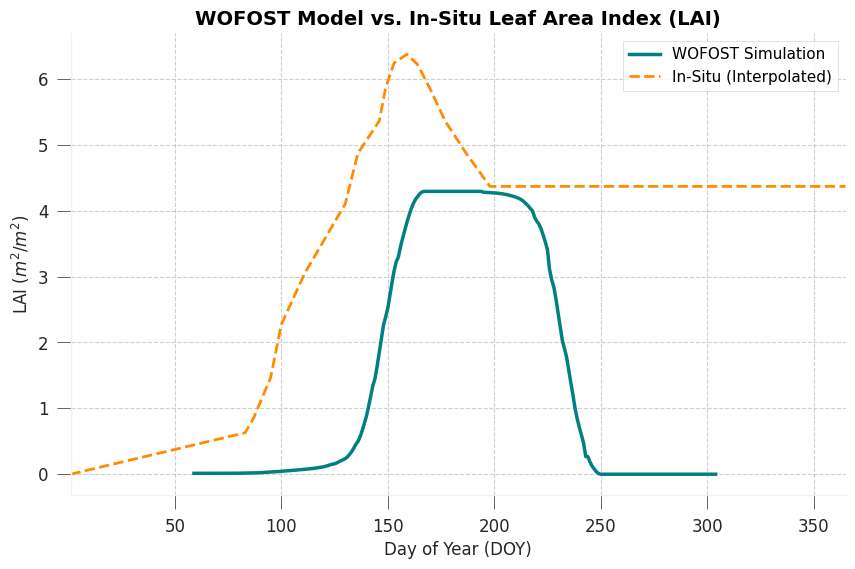

In [15]:
# Create a single figure layout
fig, ax = plt.subplots(figsize=(10, 6))

# Plot WOFOST using its index as the X-axis
wofost.plot(y="LAI", ax=ax, label="WOFOST Simulation", color="teal", linewidth=2.5)

# Plot in-situ data using its index (DOY) as the X-axis
df_extended["LAI"].plot(ax=ax, label="In-Situ (Interpolated)", color="darkorange", linestyle="--")

# Customize the chart aesthetics
ax.set_title("WOFOST Model vs. In-Situ Leaf Area Index (LAI)", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Year (DOY)", fontsize=12)
ax.set_ylabel("LAI ($m^2 / m^2$)", fontsize=12)
ax.set_xlim(1, 365)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=11)

plt.show()

### 🍂 Dry biomass

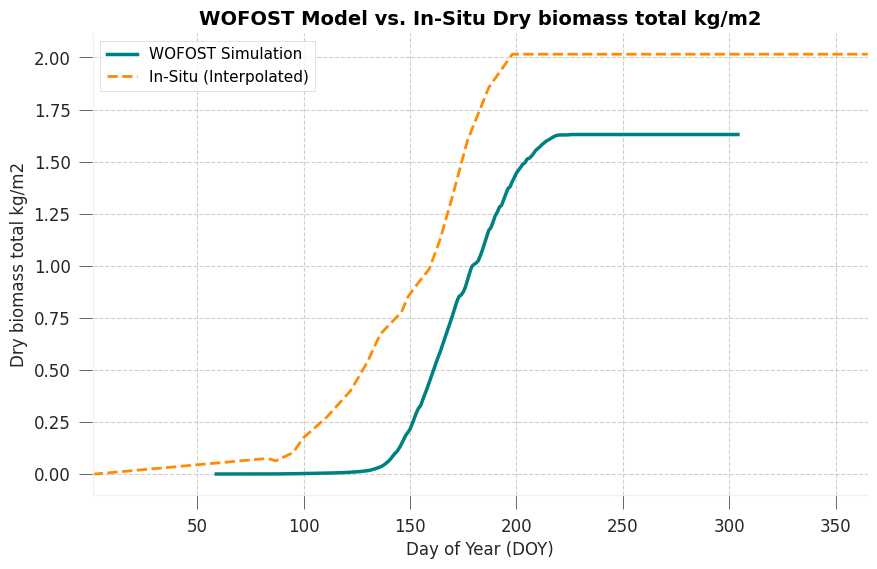

In [16]:
# Create a single figure layout
fig, ax = plt.subplots(figsize=(10, 6))

# Plot WOFOST using its index as the X-axis
ax.plot(wofost.index, wofost["TAGP"] / 10000, label="WOFOST Simulation", color="teal", linewidth=2.5)

# Plot in-situ data using its index (DOY) as the X-axis
df_extended["Dry biomass total kg/m2"].plot(ax=ax, label="In-Situ (Interpolated)", color="darkorange", linestyle="--")

# Customize the chart aesthetics
ax.set_title("WOFOST Model vs. In-Situ Dry biomass total kg/m2", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Year (DOY)", fontsize=12)
ax.set_ylabel("Dry biomass total kg/m2", fontsize=12)
ax.set_xlim(1, 365)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=11)

plt.show()

### 💧 Soil moisture

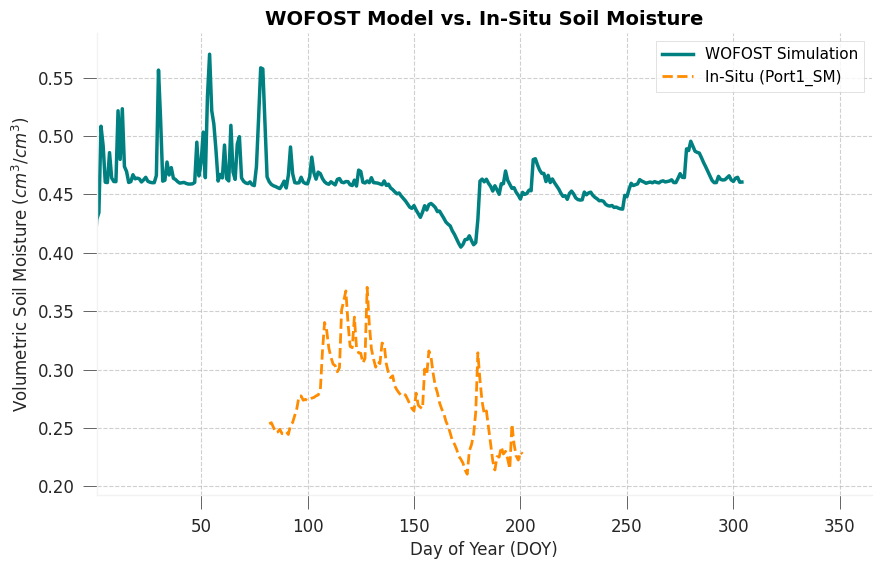

In [17]:
# Create a single figure layout
fig, ax = plt.subplots(figsize=(10, 6))

# Plot WOFOST using its index (DOY) as the X-axis
ax.plot(wofost.index, wofost["SM"], label="WOFOST Simulation", color="teal", linewidth=2.5)

# Plot in-situ data using its index (DOY) as the X-axis
sm[port].plot(ax=ax, label="In-Situ (" + port + ")", color="darkorange", linestyle="--")

# Customize the chart aesthetics
ax.set_title("WOFOST Model vs. In-Situ Soil Moisture", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Year (DOY)", fontsize=12)
ax.set_ylabel("Volumetric Soil Moisture ($cm^3 / cm^3$)", fontsize=12)
ax.set_xlim(1, 365)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=11)

plt.show()